In [ ]:
import pandas as pd

# overview of the dataset
df = pd.read_csv('biosensor_dataset_with_target.csv')

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Heart_Rate   1500 non-null   int64  
 1   Acc_X        1500 non-null   float64
 2   Acc_Y        1500 non-null   float64
 3   Acc_Z        1500 non-null   float64
 4   Gyro_X       1500 non-null   float64
 5   Gyro_Y       1500 non-null   float64
 6   Gyro_Z       1500 non-null   float64
 7   Event_Label  1500 non-null   object 
 8   Timestamp    1500 non-null   object 
 9   Athlete_ID   1500 non-null   object 
dtypes: float64(6), int64(1), object(3)
memory usage: 117.3+ KB
None


Event_Label
Start_Run       281
Stop            257
Jump_Takeoff    246
Sprint_Mid      245
Accel           241
Landing         230
Name: count, dtype: int64


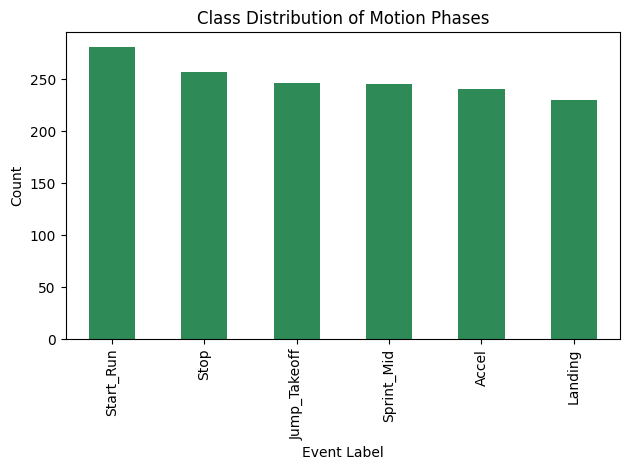

In [5]:
import matplotlib.pyplot as plt

# class distribution
counts = df['Event_Label'].value_counts()
print(counts)

counts.plot(kind='bar', color = 'seagreen')
plt.title('Class Distribution of Motion Phases')
plt.xlabel('Event Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [6]:
# check for missing vals

print(df.isnull().sum())
print(df.isnull().sum().sum())

Heart_Rate     0
Acc_X          0
Acc_Y          0
Acc_Z          0
Gyro_X         0
Gyro_Y         0
Gyro_Z         0
Event_Label    0
Timestamp      0
Athlete_ID     0
dtype: int64
0


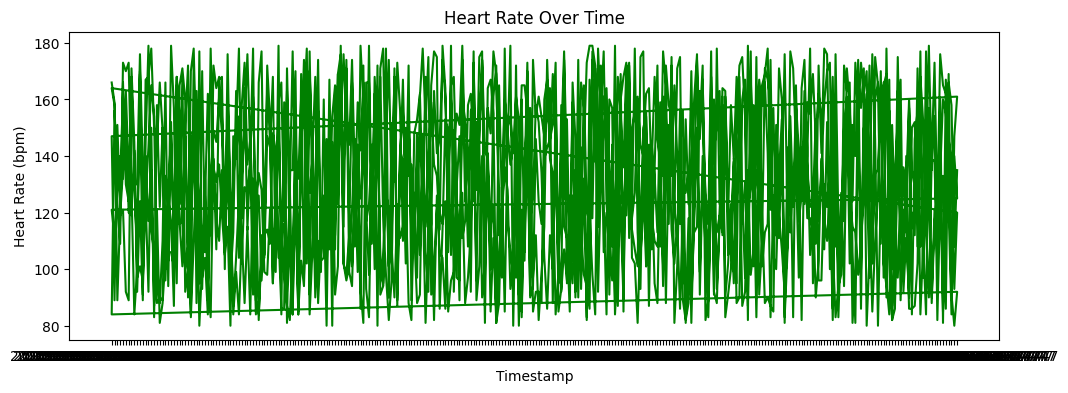

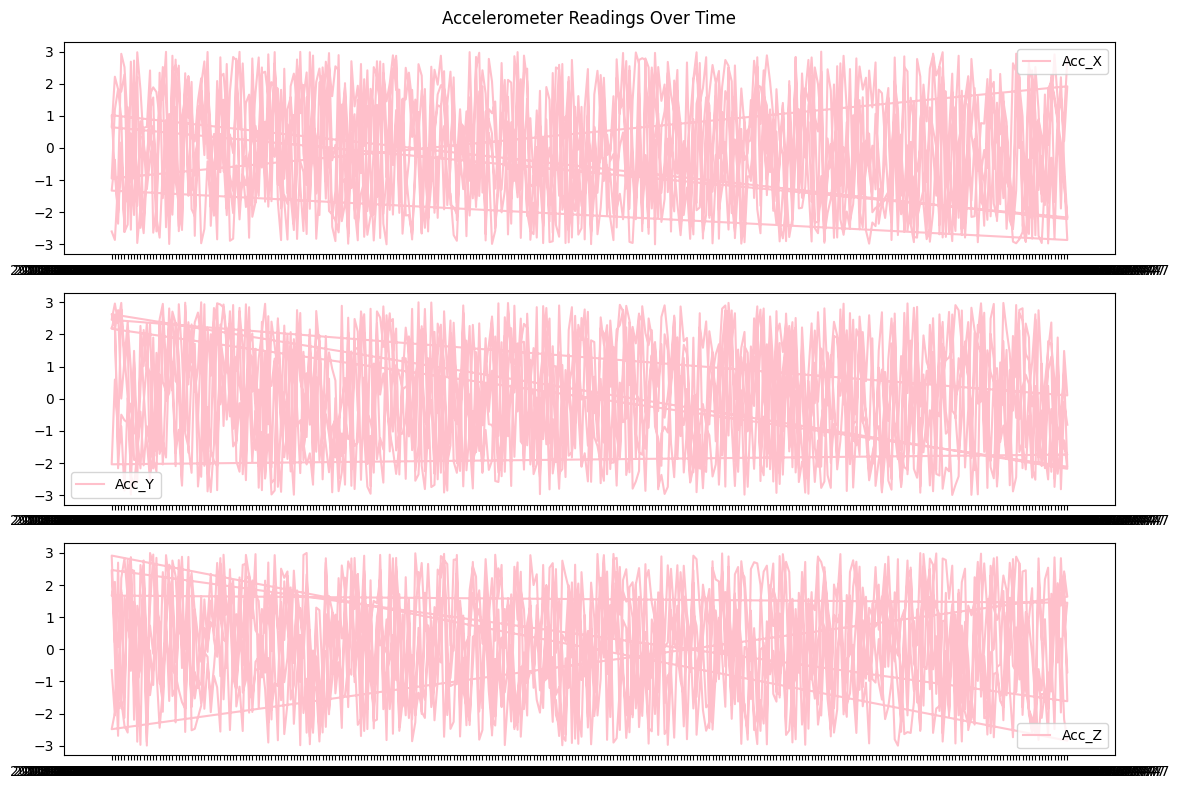

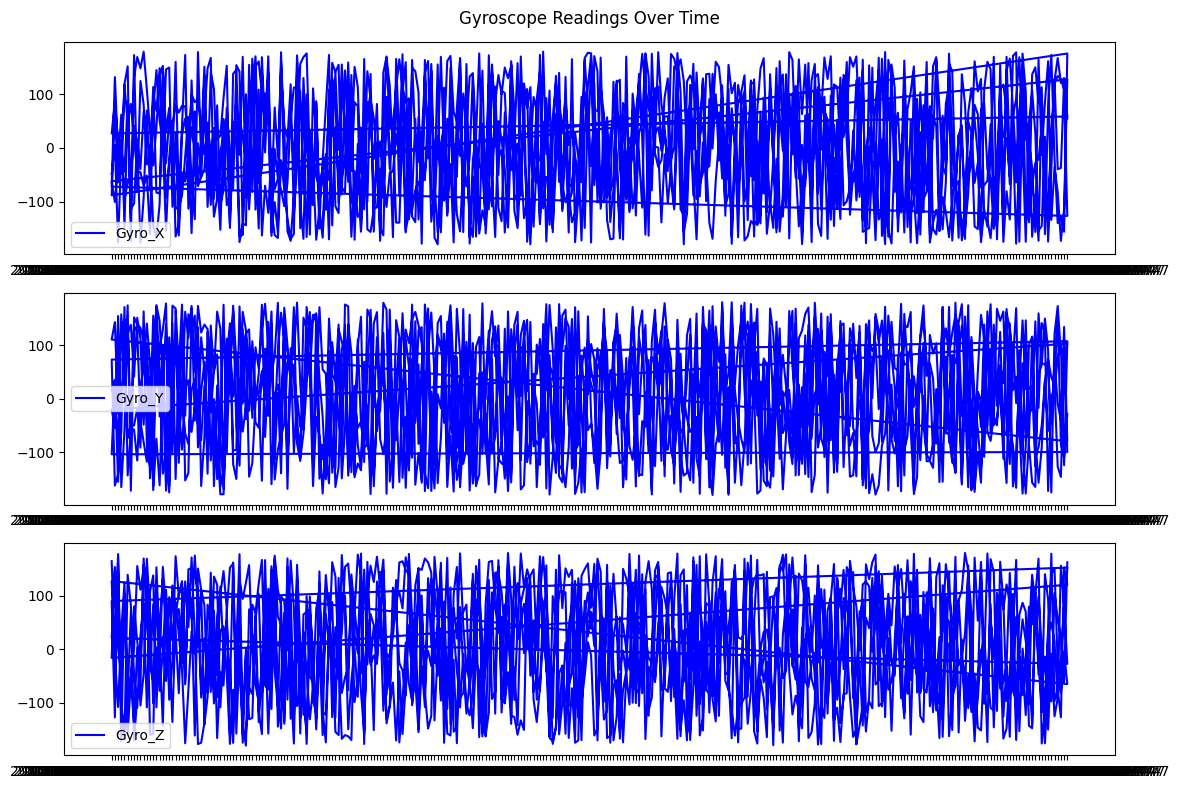

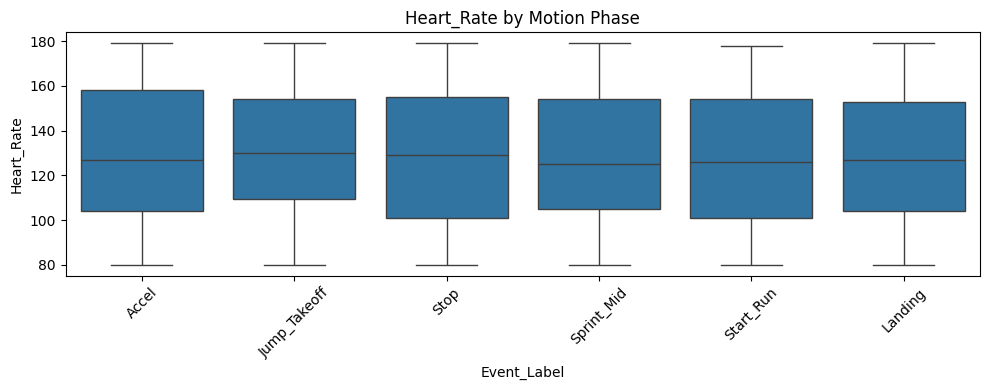

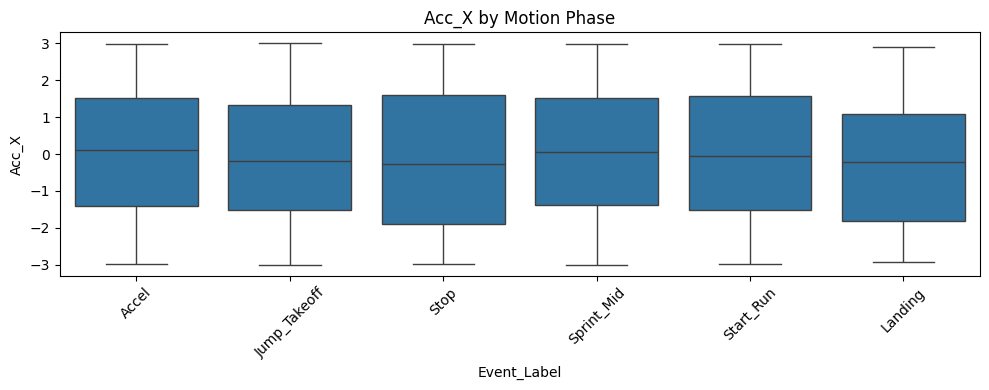

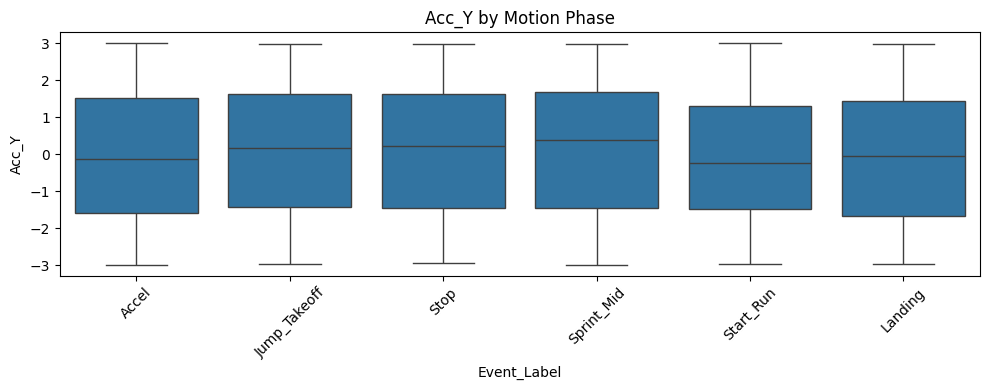

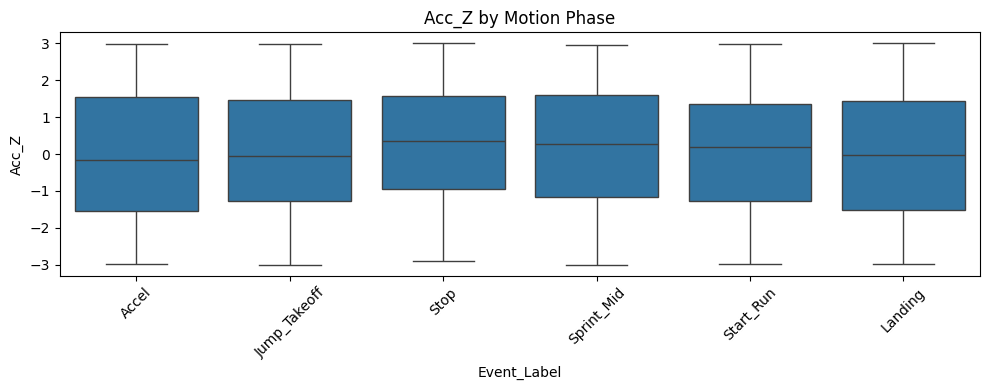

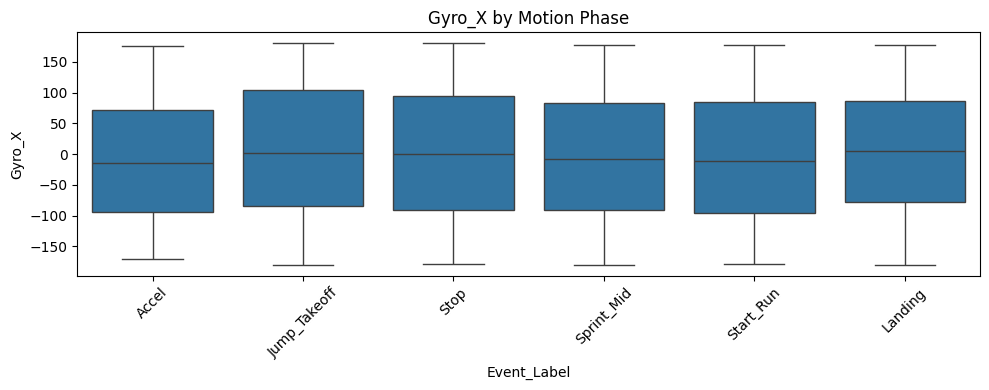

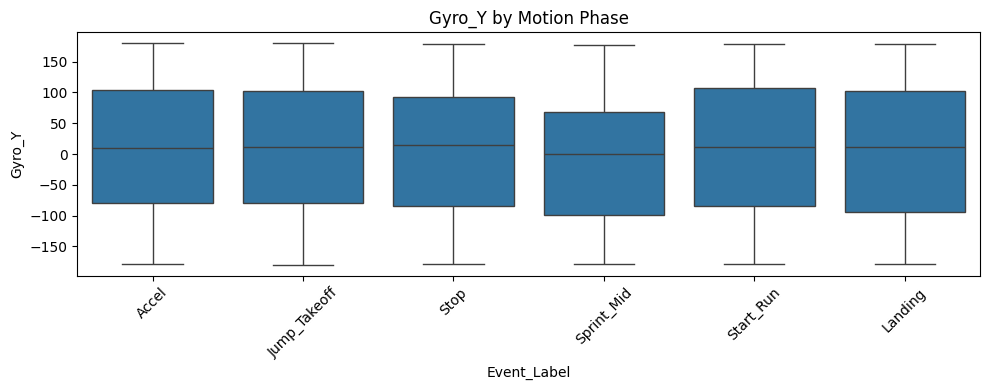

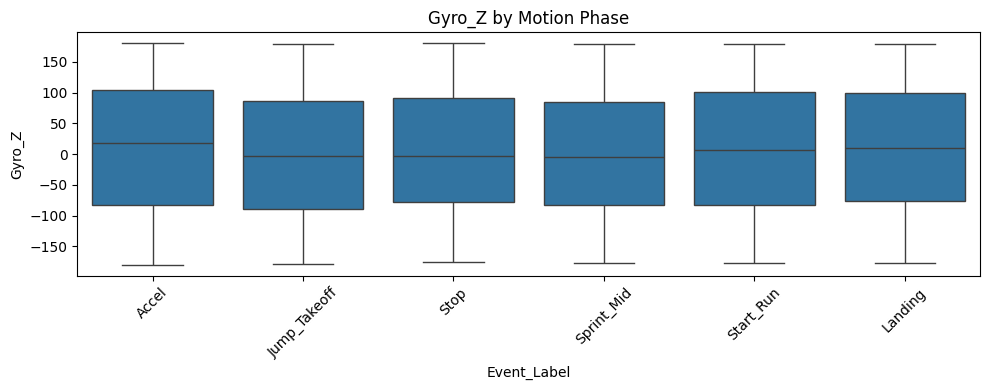

In [9]:
import seaborn as sns

# heart rate over time
plt.figure(figsize=(12, 4))
plt.plot(df['Timestamp'], df['Heart_Rate'], color='green')
plt.title('Heart Rate Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate (bpm)')
plt.show()

# accelerometer signals over time
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, col in enumerate(['Acc_X', 'Acc_Y', 'Acc_Z']):
    axes[i].plot(df['Timestamp'], df[col], color = 'pink', label=col)
    axes[i].legend()
plt.suptitle('Accelerometer Readings Over Time')
plt.tight_layout()
plt.show()

# gyroscope signals over time
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, col in enumerate(['Gyro_X', 'Gyro_Y', 'Gyro_Z']):
    axes[i].plot(df['Timestamp'], df[col], color = 'blue', label=col)
    axes[i].legend()
plt.suptitle('Gyroscope Readings Over Time')
plt.tight_layout()
plt.show()

# each sensor over motion phase
sensors = ['Heart_Rate', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']

for sensor in sensors:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Event_Label', y=sensor, data=df)
    plt.title(f'{sensor} by Motion Phase')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# overall stats
print(df.describe())

# stats grouped by motion phase
print(df.groupby('Event_Label').describe())